In [20]:
### IMPORTING NECESSARY LIBRARIES
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
from nltk.stem import PorterStemmer
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten

In [21]:
### LOADING THE SENTENCES
df = pd.read_csv('IMDB_REVIEW.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [22]:
### VIEWING THE ENTIRE CORPUS
corpus = df['review'].tolist()


print("Entire Corpus:")
print(corpus)


Entire Corpus:
["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with", 'A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes d', 'I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted come', "Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This mo", 'Petter Mattei\'s "Love in the Time of Money" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is', "Probably my all-time favorite movie, a story of selflessness, sacrifice and dedication to a noble cause, but it's not preachy or boring. It just never", 'I sure would like to see a resurrection of a up dated Seah

In [23]:
df.isnull().sum()

,0
review,0
sentiment,0


In [24]:
### UNIQUE VALUES FOR SENTIMENT
print(df['sentiment'].unique())

['positive' 'negative']


In [25]:
### MAPPING THAT 0 IS FOR NEGATIVE AND 1 IS FOR POSITIVE SENTIMENT
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [26]:
### CONVERTING STRING TO INTEGER
df['sentiment'] = df['sentiment'].astype(int)


In [27]:
y = df['sentiment'].values
print(y)

[1 1 1 ... 0 0 0]


In [28]:
### ONE HOT ENCODED OF THE TARGET CLASS
y = to_categorical(y, num_classes=2)
y

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [29]:
### TOKENIZATION AND STEMMING OF THE REVIEWS
stemmer = PorterStemmer()
def tokenize_and_stem(text):

    words = text.split()     ## splitting the reviews into words/tokens


    stemmed_words = [stemmer.stem(word) for word in words]    ## applying stemming to each words

    return ' '.join(stemmed_words)  ## joining words back into a string


df['review'] = df['review'].apply(tokenize_and_stem)



In [30]:
### ONE HOT ENCODING THE REVIEWS
vocab_size = 10000
encoded_reviews = [one_hot(review, vocab_size) for review in df['review']]


In [31]:
### PADDING TO MAKE IT EQUAL LENGTH
max_sequence_length = max([len(seq) for seq in encoded_reviews])
X_padded = pad_sequences(encoded_reviews, maxlen=max_sequence_length, padding='post')
X_padded

array([[8540, 4052, 3237, ...,    0,    0,    0],
       [ 246, 8267, 7007, ...,    0,    0,    0],
       [6140, 2963, 6955, ...,    0,    0,    0],
       ...,
       [6140,  867,  246, ...,    0,    0,    0],
       [3674, 6691, 6311, ...,    0,    0,    0],
       [9726, 8540, 5233, ...,    0,    0,    0]], dtype=int32)

In [32]:
### MODEL BUILDING AND MODEL COMPILING

model = Sequential()


embedding_dim = 100  ## feature representation dimension
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_sequence_length))


model.add(Flatten())  ## Flattening the embedding output to a 1D vector
model.add(Dense(2, activation='softmax'))  ## Output layer with 2 classes (positive/negative)
model.build(input_shape=(None, max_sequence_length))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 40, 100)             │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │           8,002 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,008,002 (3.85 MB)

 Trainable params: 1,008,002 (3.85 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
### MODEL TRAINING
history = model.fit(X_padded, y, epochs=5, batch_size=32, validation_split=0.2)

Epoch 1/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6337 - loss: 0.6291 - val_accuracy: 0.7323 - val_loss: 0.5323
Epoch 2/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8157 - loss: 0.4177 - val_accuracy: 0.7149 - val_loss: 0.5679
Epoch 3/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9382 - loss: 0.2183 - val_accuracy: 0.6968 - val_loss: 0.6722
Epoch 4/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9861 - loss: 0.0866 - val_accuracy: 0.6907 - val_loss: 0.7966
Epoch 5/5
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9982 - loss: 0.0323 - val_accuracy: 0.6898 - val_loss: 0.9268


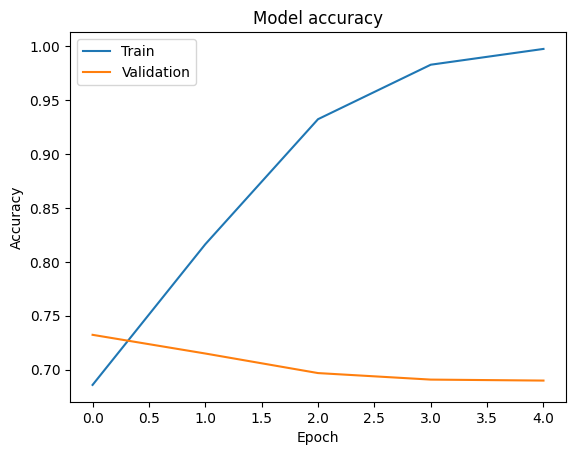

In [34]:
### PLOTTING THE TRAINING HISTORY
### ACCURACY COMPARISON
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()



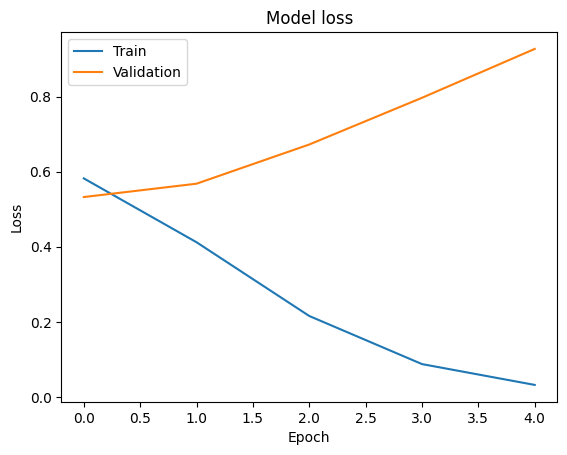

In [35]:
### LOSS COMPARISON
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [36]:
### MODEL EVALUATION
val_loss, val_acc = model.evaluate(X_padded, y, verbose=1)
print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_acc)

1550/1550 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9932 - loss: 0.0329
Validation Loss: 0.195659801363945
Validation Accuracy: 0.9379613399505615


In [37]:
### OUTLINE PREDICTIONS
test_review = ["The movie was absolutely amazing and I really enjoyed it!"]


### TOKENIZING, STEMMING, ONE HOT ENCODING THE TEST REVIEW
test_review_stemmed = [tokenize_and_stem(text) for text in test_review]
test_review_one_hot = [one_hot(review, vocab_size) for review in test_review_stemmed]


### PADDING THE TEST REVIEW
test_review_padded = np.pad(test_review_one_hot[0], (0, max_sequence_length - len(test_review_one_hot[0])), 'constant')
test_review_padded




array([3237, 2335, 6670, 1941, 2111,  356, 6140, 4269, 8844,  357,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0])

In [38]:
### MODEL PREDICTION
prediction = model.predict(np.array([test_review_padded]))

predicted_class = np.argmax(prediction, axis=1)


if predicted_class == 0:
    print("Predicted Sentiment: Negative")
else:
    print("Predicted Sentiment: Positive")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Sentiment: Positive
